In [27]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [28]:
symbol = 'MSFT'
data = yf.download(symbol,start='2021-04-01', end='2023-05-01')
data.drop(['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True, axis=1)
data.head()

[*********************100%%**********************]  1 of 1 completed


,Adj Close
Date,
2021-04-01,235.693481
2021-04-05,242.228897
2021-04-06,241.052155
2021-04-07,243.036087
2021-04-08,246.294098


In [29]:
split_date = '2023-04-01'
in_sample_data = data[:split_date]
out_of_sample_data = data[split_date:]

In [30]:
def calcRSI(data, P=14):
    data['diff_close'] = data['Adj Close'] - data['Adj Close'].shift(1)
    data['gain'] = np.where(data['diff_close'] > 0, data['diff_close'], 0)
    data['loss'] = np.where(data['diff_close'] < 0, np.abs(data['diff_close']), 0)
    
    # Calculate average gain and loss
    data['init_avg_gain'] = data['gain'].rolling(P).mean()
    data['init_avg_loss'] = data['loss'].rolling(P).mean()
    
    avg_gain = np.zeros(len(data))
    avg_loss = np.zeros(len(data))
    
    for i in range(P, len(data)):
        avg_gain[i] = (avg_gain[i-1] * (P - 1) + data['gain'].iloc[i]) / P
        avg_loss[i] = (avg_loss[i-1] * (P - 1) + data['loss'].iloc[i]) / P
    
    data['avg_gain'] = avg_gain
    data['avg_loss'] = avg_loss
    data['RS'] = data['avg_gain'] / data['avg_loss']
    data['RSI'] = 100 - (100 / (1 + data['RS']))
    
    return data

In [31]:
def calcReturns(df):
    df['returns'] = df['Adj Close'] / df['Adj Close'].shift(1)
    df['log_returns'] = np.log(df['returns'])
    df['strat_returns'] = df['position'].shift(1) * df['returns']
    df['strat_log_returns'] = df['position'].shift(1) * df['log_returns']
    df['cum_returns'] = np.exp(df['log_returns'].cumsum()) - 1
    df['strat_cum_returns'] = np.exp(df['strat_log_returns'].cumsum()) - 1
    df['peak'] = df['cum_returns'].cummax()
    df['strat_peak'] = df['strat_cum_returns'].cummax()
    return df

In [32]:
def RSI2Strategy(data, P=2, SMA1=200, SMA2=5, long_level=10, short_level=90):
    df = calcRSI(data, P=P)
    df['SMA1'] = df['Adj Close'].rolling(SMA1).mean()
    df['SMA2'] = df['Adj Close'].rolling(SMA2).mean()
    df['position'] = 0
    df.loc[(df['RSI'] < long_level) & (df['Adj Close'] > df['SMA1']), 'position'] = 1
    df.loc[(df['RSI'] > short_level) & (df['Adj Close'] < df['SMA1']), 'position'] = -1

    df = calcReturns(df)
    
    return df

In [33]:
df_in_sample = RSI2Strategy(in_sample_data.copy())
df_out_of_sample = RSI2Strategy(out_of_sample_data.copy())

In [34]:
def plot_strategy_results(in_sample_df, out_of_sample_df, title, ax):
    ax.plot(in_sample_df.index, in_sample_df['strat_cum_returns'], label='In-Sample Strategy Returns', color='blue')
    ax.plot(out_of_sample_df.index, out_of_sample_df['strat_cum_returns'], label='Out-of-Sample Strategy Returns', color='orange')
    ax.plot(in_sample_df.index, in_sample_df['cum_returns'], label='In-Sample Buy and Hold', color='lightblue', linestyle='--')
    ax.plot(out_of_sample_df.index, out_of_sample_df['cum_returns'], label='Out-of-Sample Buy and Hold', color='lightcoral', linestyle='--')

    # Shading profitability
    ax.fill_between(in_sample_df.index, in_sample_df['cum_returns'], in_sample_df['strat_cum_returns'], where=(in_sample_df['strat_cum_returns'] > in_sample_df['cum_returns']),
                    color='blue', alpha=0.2, label='In-Sample Profitability')
    ax.fill_between(out_of_sample_df.index, out_of_sample_df['cum_returns'], out_of_sample_df['strat_cum_returns'], where=(out_of_sample_df['strat_cum_returns'] > out_of_sample_df['cum_returns']),
                    color='orange', alpha=0.2, label='Out-of-Sample Profitability')

    ax.set_title(title)
    ax.set_ylabel('Cumulative Returns')
    ax.set_xlabel('Date')
    ax.legend()

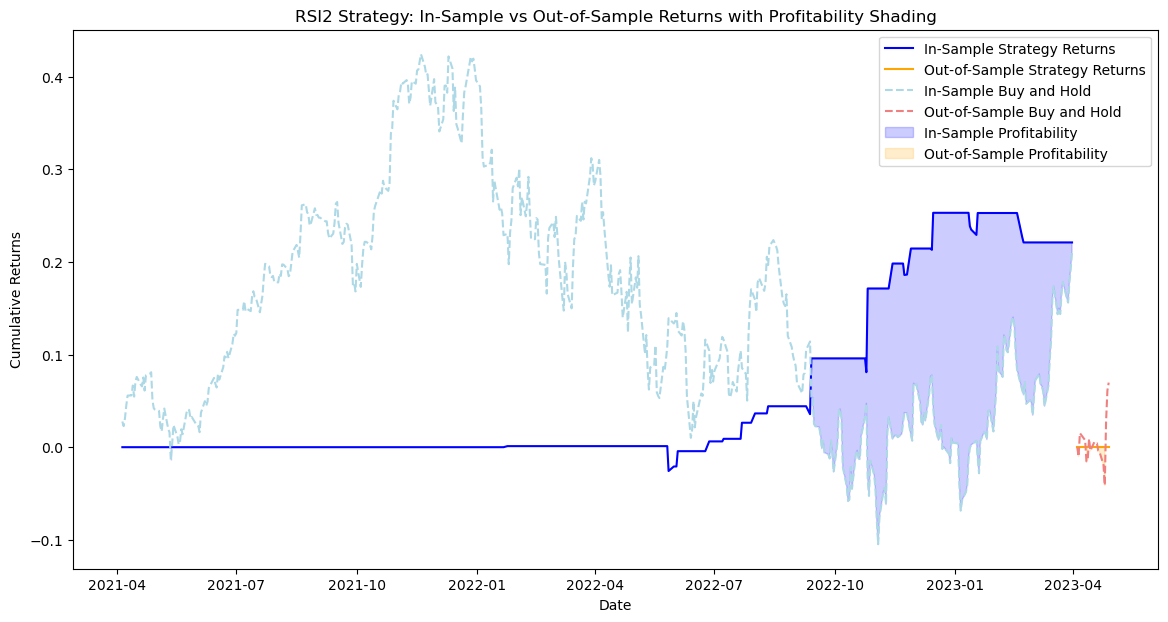

In [35]:
fig, ax = plt.subplots(figsize=(14, 7))
plot_strategy_results(df_in_sample, df_out_of_sample, 'RSI2 Strategy: In-Sample vs Out-of-Sample Returns with Profitability Shading', ax)
plt.show()